In [2]:
import json

with open("env.json", encoding="utf-8") as f:
    TOKEN = json.load(f)["token"]

In [ ]:
import requests
import time

headers = {
    "Authorization": f"Bearer {TOKEN}"
}

url = "https://qiita.com/api/v2/items"


# 記事が多すぎると上限(ページ100)に達してしまう
# だから期間を分割する
queries = [
    "created:>=2026-05-03 created:<=2026-05-18",
    "created:>=2026-05-18 created:<=2026-05-31"
]


all_items = []

for query in queries:
    print(f"取得中: {query}")

    page = 1

    while True:
        response = requests.get(
            url,
            headers=headers,
            params={
                "query": query,
                "page": page,
                "per_page": 100
            }
        )
        response.raise_for_status()

        items = response.json()

        if not items:
            break

        all_items.extend(items)

        print(f"page={page}, count={len(items)}")

        page += 1

        # レート制限対策
        time.sleep(1)

print(f"取得記事数: {len(all_items)}")

for item in all_items[:5]:
    print(
        item["title"],
        item["likes_count"],
        item["url"]
    )

取得中: created:>=2026-05-03 created:<=2026-05-18
page=1, count=100
page=2, count=100
page=3, count=100
page=4, count=100
page=5, count=100
page=6, count=100
page=7, count=100
page=8, count=100
page=9, count=100
page=10, count=100
page=11, count=100
page=12, count=100
page=13, count=100
page=14, count=100
page=15, count=100
page=16, count=100
page=17, count=100
page=18, count=100
page=19, count=100
page=20, count=100
page=21, count=100
page=22, count=100
page=23, count=100
page=24, count=100
page=25, count=100
page=26, count=100
page=27, count=100
page=28, count=100
page=29, count=100
page=30, count=100
page=31, count=100
page=32, count=100
page=33, count=100
page=34, count=100
page=35, count=100
page=36, count=100
page=37, count=100
page=38, count=100
page=39, count=100
page=40, count=100
page=41, count=100
page=42, count=100
page=43, count=100
page=44, count=100
page=45, count=100
page=46, count=100
page=47, count=100
page=48, count=100
page=49, count=100
page=50, count=100
page=51, cou

In [ ]:
# 重複除去
all_items = {
    item["id"]: item
    for item in all_items
}.values()

all_items = list(all_items)

print(f"重複除去後: {len(all_items)}")

In [ ]:
import json

items_without_body = []

for item in all_items:
    item_copy = item.copy()
    item_copy.pop("body", None)
    item_copy.pop("rendered_body", None)
    items_without_body.append(item_copy)

start_date = "2026-05-03"
end_date = "2026-05-31"

filename = f"data/qiita_items_{start_date}_{end_date}.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(
        items_without_body,
        f,
        ensure_ascii=False,
        indent=2
    )

In [3]:
# 読み込み
import json

start_date = "2026-05-03"
end_date = "2026-05-31"

filename = f"data/qiita_items_{start_date}_{end_date}.json"

with open(filename, encoding="utf-8") as f:
    articles = json.load(f)

print("全記事数:", len(articles))

全記事数: 10200


## 30いいねはどれだけレアか

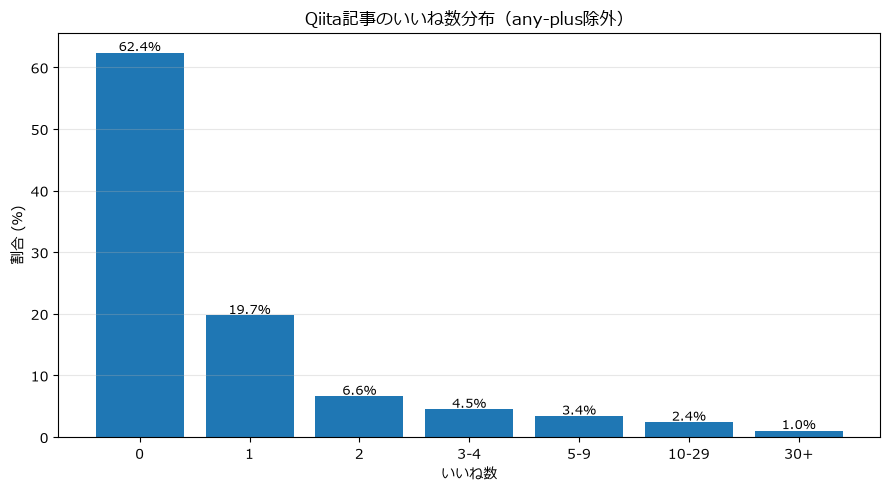

30いいね以上: 1.03%


In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Meiryo"


# any-plusを除外
likes = [
    article["likes_count"]
    for article in articles
    if article.get("organization_url_name") != "any-plus"
]

# いいね帯
bins = [
    ("0", 0, 0),
    ("1", 1, 1),
    ("2", 2, 2),
    ("3-4", 3, 4),
    ("5-9", 5, 9),
    ("10-29", 10, 29),
    ("30+", 30, float("inf")),
]

labels = [label for label, _, _ in bins]

total = len(likes)

ratios = []
for _, low, high in bins:
    count = sum(low <= x <= high for x in likes)
    ratios.append(count / total * 100)

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x, ratios)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel("割合 (%)")
ax.set_xlabel("いいね数")
ax.set_title("Qiita記事のいいね数分布（any-plus除外）")

ax.grid(axis="y", alpha=0.3)

# 値を表示
for i, v in enumerate(ratios):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# 30いいね以上の割合
print(f"30いいね以上: {ratios[-1]:.2f}%")